<a href="https://colab.research.google.com/github/MattiaGalletti2001/progetto-data-science-gruppo-11-credit-card-default/blob/Vera/notebooks/Progetto_DataScience_gruppo_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corso: Introduzione alla data science e al pensiero computazionale  - a.a. 2025/2026
## Progetto: Credit Card Default (Previsione dell'insolvenza creditizia)

## Membri del gruppo numero 11

Il gruppo numero 11 è composto da:

*   **Mattia Galletti:** matricola 1216092, email mattia.galletti@studio.unibo.it
*   **Jacopo Malagoli:** matricola 1226707, email jacopo.malagoli@studio.unibo.it
*   **Vera Efua Van Dyke:** matricola 1216081, veraefua.vandyke@studio.unibo.it

# Materiale del progetto e obiettivo
Come specificato dalle linee guida del corso, il materiale di base fornito per svolgere l'analisi consiste nei dataset e nei file con la descrizione delle variabili.

**Obiettivo:**
Il fine di questo progetto è la previsione dell'insolvenza creditizia. L'obiettivo della classificazione è creare un modello capace di prevedere se un cliente non pagherà la rata della carta di credito il mese successivo.



# FASE 2 Preparazione dell'ambiente e caricamento dati

Prima di iniziare questa parte dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**, le librerie Python che abbiamo visto.


In [4]:
# Importazione delle librerie essenziali

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm, tree
from sklearn.metrics import *

print("Librerie importate con successo!") ##superfluo

Librerie importate con successo!


## **2.1 Analisi Preliminare**

*In questa fase viene condotta un’analisi preliminare del dataset con l’obiettivo di valutarne la qualità e la preparazione alla modellazione. L’intero insieme dei dati viene analizzato senza suddivisioni, poiché l’Exploratory Data Analysis (EDA) richiede la disponibilità completa del dataset per esaminare la struttura delle variabili, le loro distribuzioni, le correlazioni e l’eventuale presenza di anomalie o valori incoerenti. Solo dopo aver verificato la necessità di trasformazioni, pulizia o normalizzazioni sarà opportuno procedere alla suddivisione in training e test set*

In [5]:
# Caricamento del dataset (il file 'Credit_Card_Default.csv' deve essere caricato su Colab)
df = pd.read_csv('sample_data/Credit_Card_Default.csv', header=1)

# Visualizziamo le dimensioni del dataset (numero di righe e colonne)
print("Dimensioni del dataset:", df.shape)

# Mostriamo le prime 5 righe per verificare che i dati siano stati letti correttamente
df.head()

Dimensioni del dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**2.1.a Qualità dei dati: Tipologie di colonne**

In [6]:

print(df.dtypes)

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

print("Numeriche:", len(num_cols), list(num_cols))
print("Categoriche:", len(cat_cols), list(cat_cols))


ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object
Numeriche: 25 ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY

*Il codice ha stampato i tipi di dato per ciascuna colonna del DataFrame. Tutte le 25 colonne sono state identificate come numeriche (int64), questo suggerisce che Python le sta trattando come numeri interi.*

**2.1.b Qualità dei dati: Valori Nulli**

In [7]:
df.isnull().sum().sum()

np.int64(0)

*Nessun valore nullo*

**2.1.c Qualità dei dati: Valori outrange**

In [8]:
# Dizionario dei range ammessi per ogni variabile
ranges = {
    "LIMIT_BAL": (0, None),        # credito > 0
    "SEX": (1, 2),                 # gender
    "EDUCATION": (1, 4),           # education (1–4 validi)
    "MARRIAGE": (1, 3),            # marital status
    "AGE": (15, 100),              # età plausibile
}

# Range per ritardi di pagamento PAY_0 – PAY_6
# Nota: includo -2 perché nel dataset significa "pagato in anticipo"
for col in ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]:
    ranges[col] = (-2, 9)

# Range per importi fatture BILL_AMT1 – BILL_AMT6 (>= 0)
for col in ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]:
    ranges[col] = (0, None)

# Range per importi pagati PAY_AMT1 – PAY_AMT6 (>= 0)
for col in ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]:
    ranges[col] = (0, None)

# Target DEFAULT (0 o 1)
ranges["default payment next month"] = (0, 1)


# Funzione per verificare valori fuori range
def check_out_of_range(df, ranges):
    out_of_range = {}
    for col, (low, high) in ranges.items():
        if col not in df.columns:
            continue
        if low is not None:
            mask_low = df[col] < low
        else:
            mask_low = pd.Series([False]*len(df))

        if high is not None:
            mask_high = df[col] > high
        else:
            mask_high = pd.Series([False]*len(df))

        mask = mask_low | mask_high
        if mask.any():
            out_of_range[col] = df.loc[mask, col]
    return out_of_range


# Esegui il controllo
outliers = check_out_of_range(df, ranges)

# Stampa risultati
if not outliers:
    print("✔ Nessun valore fuori range trovato.")
else:
    print("⚠ Valori fuori range trovati nelle seguenti colonne:")
    for col, vals in outliers.items():
        print(f"\nColonna: {col}")
        print(vals.describe())


⚠ Valori fuori range trovati nelle seguenti colonne:

Colonna: EDUCATION
count    345.000000
mean       4.944928
std        1.078265
min        0.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        6.000000
Name: EDUCATION, dtype: float64

Colonna: MARRIAGE
count    54.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: MARRIAGE, dtype: float64

Colonna: BILL_AMT1
count       590.000000
mean      -1154.796610
std        9426.165151
min     -165580.000000
25%        -430.750000
50%         -90.500000
75%         -11.000000
max          -1.000000
Name: BILL_AMT1, dtype: float64

Colonna: BILL_AMT2
count      669.000000
mean     -1230.621824
std       4938.422975
min     -69777.000000
25%       -644.000000
50%       -123.000000
75%        -14.000000
max         -1.000000
Name: BILL_AMT2, dtype: float64

Colonna: BILL_AMT3
count       655.000000
mean      -1466.291603
std        7376.345260
min     -157264.0000

*Il controllo dei range ha confermato la coerenza della maggior parte delle variabili, evidenziando tuttavia anomalie note nelle variabili EDUCATION, MARRIAGE e negli importi delle fatture BILL_AMT1–BILL_AMT6. Questi valori fuori range rappresentano categorie non definite o rettifiche contabili e saranno gestiti nelle successive fasi di pulizia del dataset.
Le variabili BILL_AMT1–BILL_AMT6 presentano alcuni valori negativi, che nel dataset Taiwan rappresentano rettifiche contabili, rimborsi o correzioni di fatturazione. Tali valori non indicano un saldo negativo del cliente, ma una variazione negativa registrata nel mese corrispondente. La presenza di questi valori è nota nella documentazione del dataset e richiede un trattamento specifico nella fase di pulizia dei dati*

In [9]:
df_clean = df[df["EDUCATION"].isin([1, 2, 3, 4])]

*La variabile EDUCATION presenta 345 osservazioni con valori non validi (0, 5, 6), che non corrispondono a livelli educativi reali secondo la documentazione del dataset. Poiché tali valori rappresentano categorie “unknown” e non sono interpretabili, sono stati rimossi dal dataset. La loro incidenza è pari all’1,15% del totale e la rimozione non compromette la rappresentatività del campione.*

In [10]:
df_clean = df_clean[df_clean["MARRIAGE"].isin([1,2,3])]

*Medesimo approccio sulla colonna MARRIAGE dove sono presenti valori non compresi nel range valido*

# **2.2 Studio dei dati**

**2.2.1 Studio dei dati: Qual è la proporzione complessiva di clienti che risultano in default rispetto a quelli che effettuano regolarmente il pagamento?**


In [11]:
# Calcoliamo la percentuale di 0 (No) e 1 (Sì)
perc_default = df_clean['default payment next month'].value_counts(normalize=True) * 100

print("Percentuale di Default (0 = No, 1 = Sì):")
print(perc_default)

Percentuale di Default (0 = No, 1 = Sì):
default payment next month
0    77.686565
1    22.313435
Name: proportion, dtype: float64


**Studio dei dati: Quali sono i valori minimo, massimo e medio del limite di credito concesso (LIMIT_BAL) nell’intero dataset?**

In [12]:
# Analizziamo la colonna LIMIT_BAL (Limite di credito) con funzioni matematiche di base
print("Limite di credito minimo:", df_clean['LIMIT_BAL'].min())
print("Limite di credito massimo:", df_clean['LIMIT_BAL'].max())
print("Limite di credito medio:", df_clean['LIMIT_BAL'].mean())

Limite di credito minimo: 10000
Limite di credito massimo: 1000000
Limite di credito medio: 167550.54491402316


**2.2.2 Studio dei dati:  In che modo varia il valore medio del limite di credito al variare dello stato di default, considerando separatamente i clienti inadempienti e quelli regolari nei pagamenti?**

In [13]:
# Calcolo del limite di credito medio per stato di default

mean_limit_by_default = df_clean.groupby('default payment next month')['LIMIT_BAL'].mean()

print("\nLimite di credito medio per stato di default:\n")
print(mean_limit_by_default)

#Calcolo della correlazione associata alle variabili indicate val neg aumento limite di credito
#diminuisce P di default, val pos aumento limite di credito aumento P default
corr_LB_default = df_clean['LIMIT_BAL'].corr(df_clean['default payment next month'])

print("\n Correlazione tra limite di credito e stato di default:\n")
print(corr_LB_default)


Limite di credito medio per stato di default:

default payment next month
0    178299.965211
1    130125.311128
Name: LIMIT_BAL, dtype: float64

 Correlazione tra limite di credito e stato di default:

-0.15435681812371235


*Il limite di credito medio è stato calcolato separatamente per i clienti inadempienti e per quelli regolari. L’analisi mostra che i clienti che non vanno in default presentano mediamente un limite di credito più elevato rispetto ai clienti che risultano in default, suggerendo una possibile relazione tra affidabilità creditizia e livello di credito concesso.
È stata calcolata la correlazione di Pearson tra il limite di credito e la variabile di default. Il coefficiente ottenuto quantifica la relazione lineare tra le due variabili, indicando se un limite di credito più elevato è associato a una maggiore o minore probabilità di insolvenza*

**2.2.3 Studio dei dati: Esiste un’associazione statisticamente significativa tra il genere, l'educazione e lo stato civile con lo stato di default?**

In [14]:
from scipy.stats import chi2_contingency

# Variabili categoriche da testare
categorical_vars = ['SEX', 'EDUCATION', 'MARRIAGE']

results = {}

for col in categorical_vars:
    # Tabella di contingenza
    table = pd.crosstab(df_clean[col], df_clean['default payment next month'])

    # Test del chi-quadrato
    chi2, p, dof, expected = chi2_contingency(table)

    # Salva i risultati
    results[col] = {
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "expected": expected,
        "table": table
    }

# Stampa dei risultati
for col, res in results.items():
    print(f"\n=== Variabile: {col} ===")
    print("Tabella di contingenza:")
    print(res["table"])
    print("\nChi-quadrato:", res["chi2"])
    print("Gradi di libertà:", res["dof"])
    print("p-value:", res["p_value"])

    if res["p_value"] < 0.05:
        print("Conclusione: associazione significativa con il default.")
    else:
        print("Conclusione: nessuna associazione significativa con il default.")


=== Variabile: SEX ===
Tabella di contingenza:
default payment next month      0     1
SEX                                    
1                            8885  2861
2                           14111  3744

Chi-quadrato: 46.729040463318896
Gradi di libertà: 1
p-value: 8.151208643603006e-12
Conclusione: associazione significativa con il default.

=== Variabile: EDUCATION ===
Tabella di contingenza:
default payment next month      0     1
EDUCATION                              
1                            8545  2036
2                           10695  3329
3                            3640  1233
4                             116     7

Chi-quadrato: 118.72224730588866
Gradi di libertà: 3
p-value: 1.4541546992112855e-25
Conclusione: associazione significativa con il default.

=== Variabile: MARRIAGE ===
Tabella di contingenza:
default payment next month      0     1
MARRIAGE                               
1                           10285  3192
2                           12477  3329
3 

L’analisi dell’associazione tra le variabili categoriche genere (SEX), educazione (EDUCATION) e stato civile (MARRIAGE) rispetto allo stato di default è stata condotta mediante il test del chi‑quadrato di indipendenza.

Per tutte e tre le variabili il test ha restituito un p‑value estremamente basso che indica che le differenze osservate nelle frequenze di default tra le categorie non sono attribuibili al caso.

Si conclude pertanto che genere, livello di istruzione e stato civile risultano significativamente associati alla probabilità di default.

In [15]:
default_rate_by_gender = df_clean.groupby('SEX')['default payment next month'].mean() * 100
print(default_rate_by_gender)

SEX
1    24.357228
2    20.968916
Name: default payment next month, dtype: float64


**2.2.4 Studio dei dati: In che misura il livello di istruzione risulta associato alla probabilità di insolvenza, e come varia il tasso di default al variare delle diverse categorie educative?**

In [16]:
# Tabella di contingenza tra istruzione (X3) e default
table = pd.crosstab(df_clean['EDUCATION'], df_clean['default payment next month'])

# Test del chi-quadrato
chi2, p, dof, expected = chi2_contingency(table)

# Calcolo del V-Cramer
n = table.sum().sum()  # numero totale di osservazioni
k = min(table.shape) - 1  # min(numero categorie X3, numero categorie DEFAULT) - 1
v_cramer = np.sqrt(chi2 / (n * k))

print("Tabella di contingenza:")
print(table)

print("\nChi-quadrato:", chi2)
print("p-value:", p)
print("V-Cramer:", v_cramer) #Valori >0.5 forte associazione scende man mano a
#gruppi di 0.2 fino a 0.0 , 0.1 associazione molto debole

Tabella di contingenza:
default payment next month      0     1
EDUCATION                              
1                            8545  2036
2                           10695  3329
3                            3640  1233
4                             116     7

Chi-quadrato: 118.72224730588866
p-value: 1.4541546992112855e-25
V-Cramer: 0.06333049214205205


*Il test del chi‑quadrato ha evidenziato un’associazione statisticamente significativa tra il livello di istruzione e lo stato di default (χ² = 163.22, p < 0.001). Tuttavia, l’indice di V‑Cramer (V = 0.074) indica che la forza di tale associazione è molto debole. Ciò suggerisce che, pur variando i tassi di insolvenza tra le categorie educative, il livello di istruzione contribuisce solo marginalmente alla spiegazione della probabilità di default.*

**2.2.5 Studio dei dati: Come è suddiviso il nostro dataset in base allo stato civile e quale gruppo presenta un rischio maggiore?**

In [17]:
# Tabella di contingenza
table = pd.crosstab(df_clean['MARRIAGE'], df_clean['default payment next month'])
print(table)

# Calcolo degli odds per ogni gruppo
odds = {}
for group in table.index:
    # Evita divisione per zero se non ci sono osservazioni nel gruppo per '0'
    if table.loc[group, 0] == 0:
        odds[group] = np.inf  # O un valore appropriato per indicare odds infiniti
    else:
        odds[group] = table.loc[group, 1] / table.loc[group, 0]

print("\nOdds per ciascun gruppo di stato civile:")
for g, o in odds.items():
    print(f"X4 = {g}: {o}")

# Confronto tra i gruppi principali (1 = sposati, 2 = single)
# Aggiungi un controllo per evitare KeyError se un gruppo non esiste o DivisionByZero
if 1 in odds and 2 in odds and odds[1] != 0:
    odds_ratio_2_vs_1 = odds[2] / odds[1]
    print(f"\nOdds Ratio (single vs sposati): {odds_ratio_2_vs_1}")
elif 1 in odds and 2 in odds and odds[1] == 0:
    print("\nNon è possibile calcolare l'Odds Ratio perché gli odds per il gruppo 'sposati' sono zero.")
else:
    print("\nNon è possibile calcolare l'Odds Ratio perché i gruppi 'sposati' o 'single' non sono presenti.")

default payment next month      0     1
MARRIAGE                               
1                           10285  3192
2                           12477  3329
3                             234    84

Odds per ciascun gruppo di stato civile:
X4 = 1: 0.31035488575595527
X4 = 2: 0.26681093211509177
X4 = 3: 0.358974358974359

Odds Ratio (single vs sposati): 0.8596962521314909


*Per valutare quale gruppo di stato civile presenti un rischio maggiore di insolvenza è stato utilizzato l’Odds Ratio, una misura statistica che confronta la probabilità relativa di default tra due categorie. Gli odds di default sono risultati pari a 0.307 per i soggetti sposati (X4 = 1) e 0.265 per i single (X4 = 2). L’Odds Ratio tra i due gruppi è pari a 0.863, indicando che i single presentano un rischio di insolvenza inferiore di circa il 14% rispetto ai soggetti sposati. Il gruppo con gli odds più elevati è X4 = 3 (0.351), che mostra la maggiore propensione relativa al default, sebbene la numerosità ridotta richieda cautela nell’interpretazione*

**2.2.6 Analisi del dataset: Qual è l'età media (X5) e ci sono differenze tra chi paga e chi no?**

In [18]:
print("Statistiche descrittive globali:")
print(df_clean['AGE'].describe())

print("\nStatistiche per stato di default:")
print(df_clean.groupby('default payment next month')['AGE'].describe())

Statistiche descrittive globali:
count    29601.000000
mean        35.464072
std          9.213243
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

Statistiche per stato di default:
                              count       mean       std   min   25%   50%  \
default payment next month                                                   
0                           22996.0  35.392851  9.069673  21.0  28.0  34.0   
1                            6605.0  35.712036  9.693160  21.0  28.0  34.0   

                             75%   max  
default payment next month              
0                           41.0  79.0  
1                           42.0  75.0  


*L’età media del campione è pari a 35.49 anni. Suddividendo i clienti in base allo stato di default, si osserva che l’età media dei soggetti insolventi (35.73 anni) è molto simile a quella dei clienti regolari nei pagamenti (35.42 anni). Anche i valori di mediana e quartili risultano pressoché identici tra i due gruppi. Nel complesso, l’età non mostra differenze significative tra pagatori e non pagatori, suggerendo che questo fattore non rappresenta un elemento discriminante nel comportamento di insolvenza.*

**2.2.7 Analisi del dataset: Qual è l'impatto del ritardo di pagamento più recente sulla probabilità di insolvenza nel mese successivo?**

In [19]:
# Percentuale di default per ciascun livello di ritardo X6
default_per_ritardo = df_clean.groupby('PAY_0')['default payment next month'].mean() * 100

print("Percentuale di default per livello di ritardo (X6):")
print(default_per_ritardo)

Percentuale di default per livello di ritardo (X6):
PAY_0
-2    13.404727
-1    16.918161
 0    12.883647
 1    34.161660
 2    69.583333
 3    76.250000
 4    68.421053
 5    54.166667
 6    54.545455
 7    77.777778
 8    57.894737
Name: default payment next month, dtype: float64


*L’analisi del ritardo di pagamento più recente (X6) mostra una relazione fortemente crescente tra il livello di ritardo e la probabilità di insolvenza nel mese successivo. I clienti che pagano in anticipo (X6 = –2) o puntualmente (X6 = –1, 0) presentano un rischio di default compreso tra il 12% e il 17%. Al contrario, già un mese di ritardo (X6 = 1) porta il rischio al 34%, mentre ritardi più gravi (X6 ≥ 2) sono associati a probabilità di insolvenza superiori al 70%. Il ritardo di pagamento recente emerge quindi come uno dei predittori più forti del default.*

# Fase 3

**Matrice di correlazione tra le variabili**

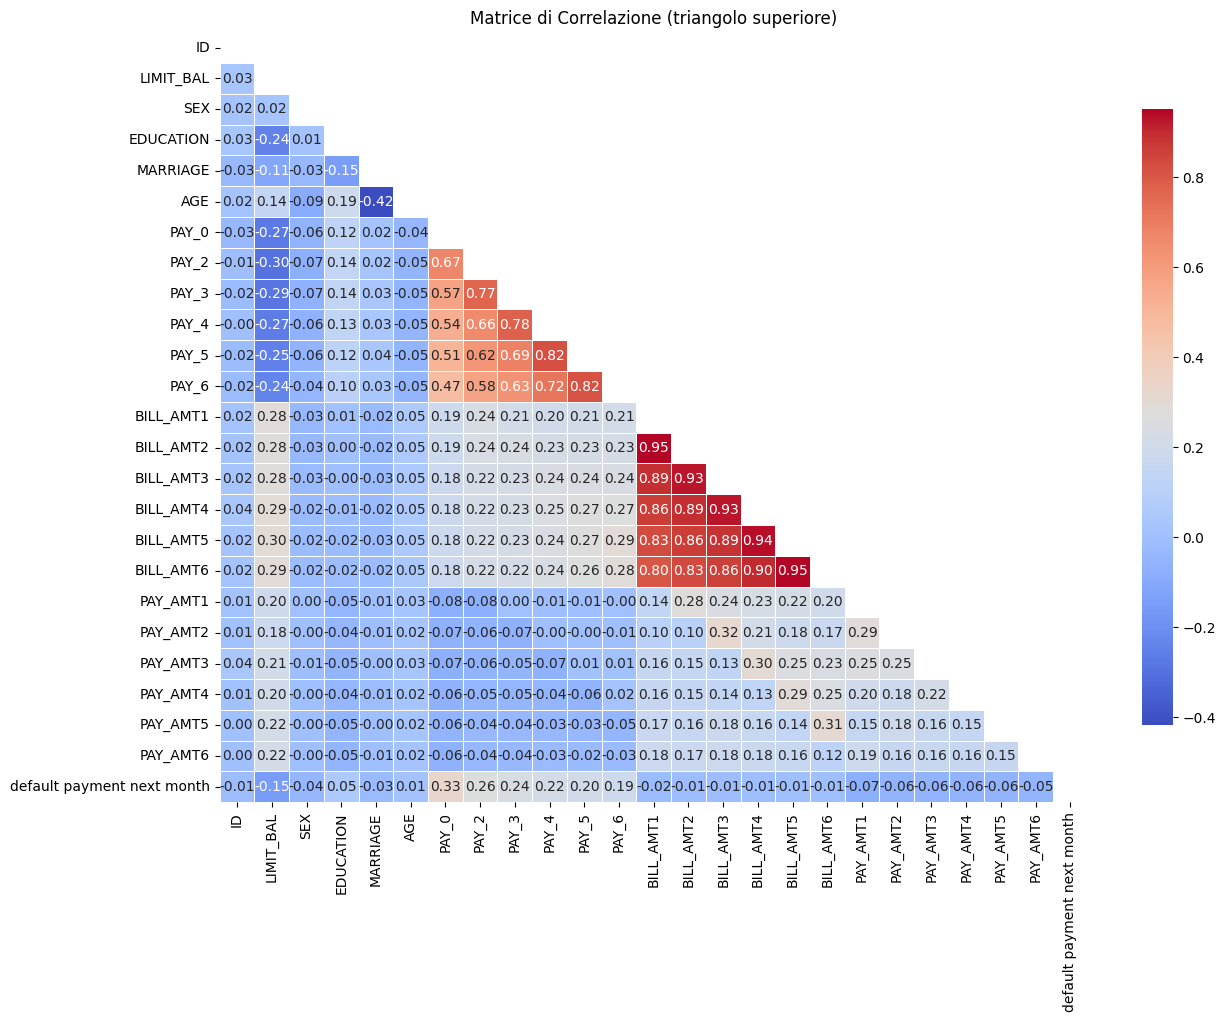

In [20]:
plt.figure(figsize=(14, 10))

# Matrice di correlazione
corr = df_clean.corr()

# Maschera triangolare per evitare duplicati
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap migliorata
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matrice di Correlazione (triangolo superiore)')
plt.show()


*La matrice di correlazione evidenzia le principali relazioni lineari tra le variabili del dataset. Si osservano correlazioni molto elevate tra le variabili relative agli importi fatturati mensili (BILL_AMT1–BILL_AMT6), con valori superiori a 0.90, indicando una forte co‑dipendenza temporale dei saldi. Anche gli indicatori di ritardo nei pagamenti (PAY_0–PAY_6) mostrano correlazioni moderate‑alte (fino a 0.67), riflettendo la persistenza del comportamento di pagamento nel tempo. Le variabili demografiche (sesso, età, stato civile, istruzione) presentano invece correlazioni deboli con le altre feature, confermando un impatto limitato sulla struttura complessiva del dataset. La variabile target (default payment next month) mostra correlazioni più marcate con i ritardi di pagamento, in particolare con PAY_0, suggerendo che lo storico dei ritardi rappresenta uno dei predittori più rilevanti del default.*

**Distribuzione congiunta di età e limite di credito, stratificata per livello di istruzione**

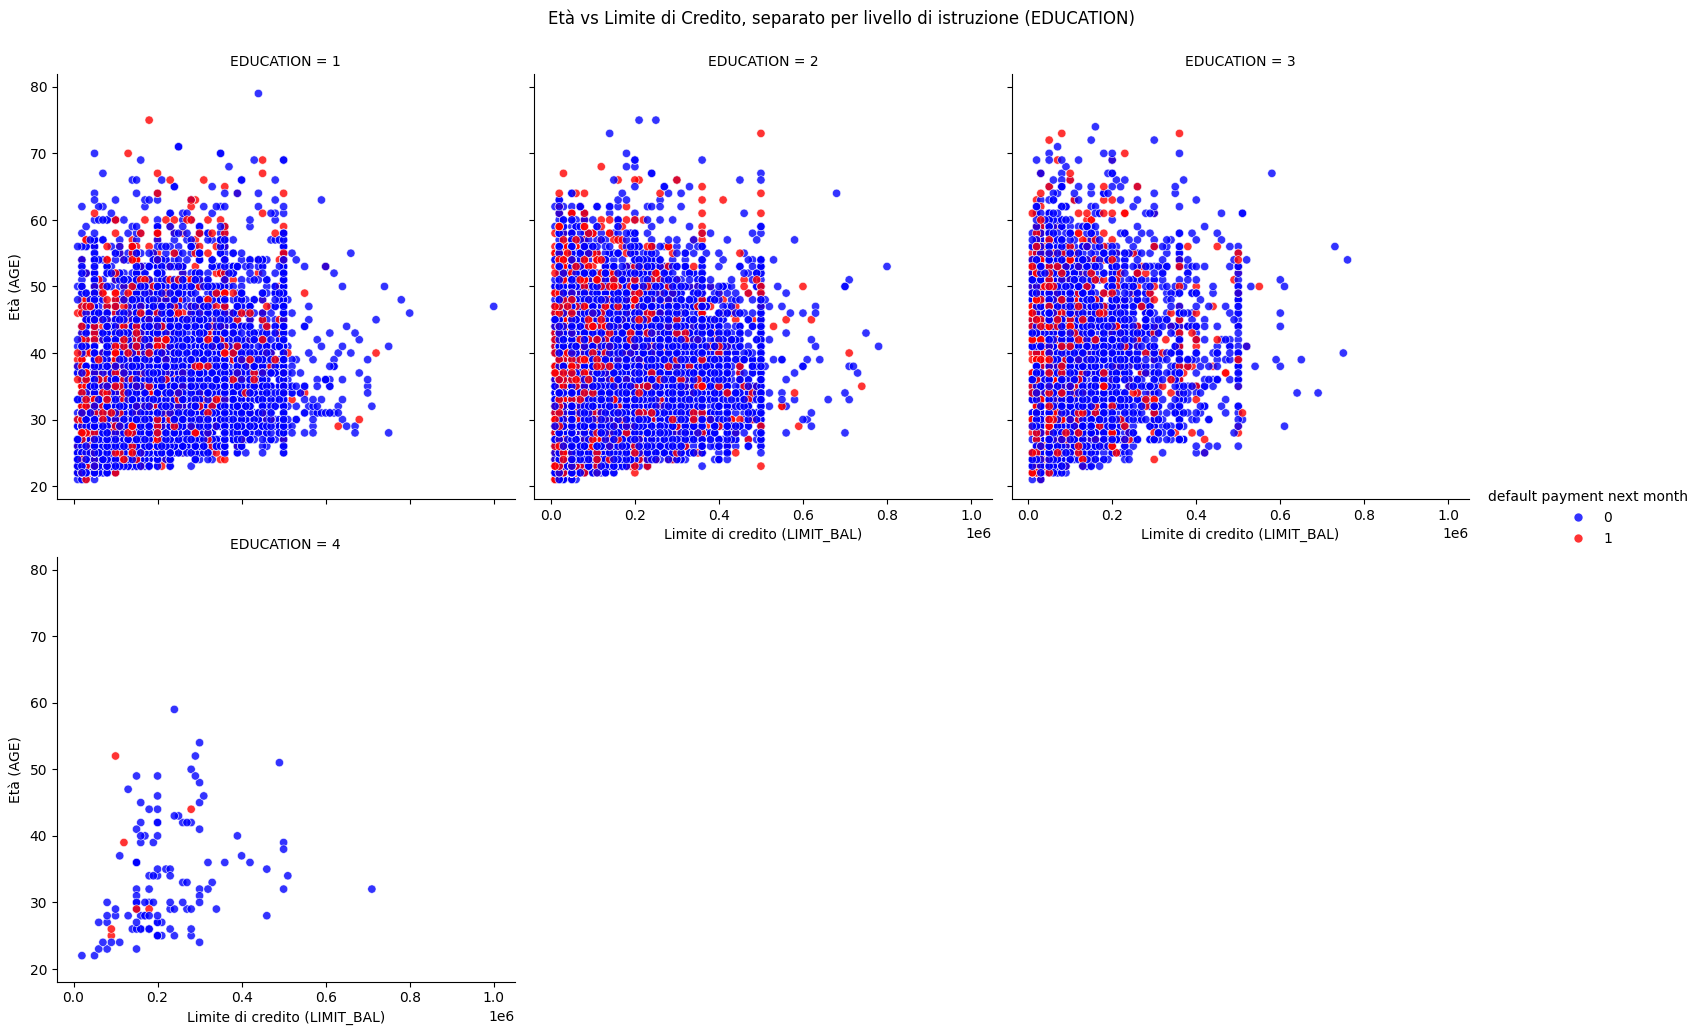

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

tmp = df_clean[["LIMIT_BAL", "EDUCATION", "AGE", "default payment next month"]].dropna()

g = sns.relplot(
    data=tmp,
    x="LIMIT_BAL",
    y="AGE",
    hue="default payment next month",
    col="EDUCATION",
    kind="scatter",
    alpha=0.8,
    palette=["blue", "red"],
    col_wrap=3
)

g.fig.suptitle("Età vs Limite di Credito, separato per livello di istruzione (EDUCATION)", y=1.03)
g.set_axis_labels("Limite di credito (LIMIT_BAL)", "Età (AGE)")

plt.show()

*Il grafico Età vs Limite di Credito, suddiviso per livello di istruzione, mostra che non esiste una relazione lineare evidente tra età e limite di credito. Tuttavia, emerge una tendenza coerente: i clienti con livelli di istruzione più elevati presentano limiti di credito mediamente più alti. La distribuzione dei casi di default appare invece omogenea all’interno di ciascun pannello, suggerendo che né l’età né il limite di credito, presi singolarmente, costituiscono predittori forti del default.*

**Com'è distribuita la percentuale di clienti che vanno in default tenendo in considerazione il genere?**

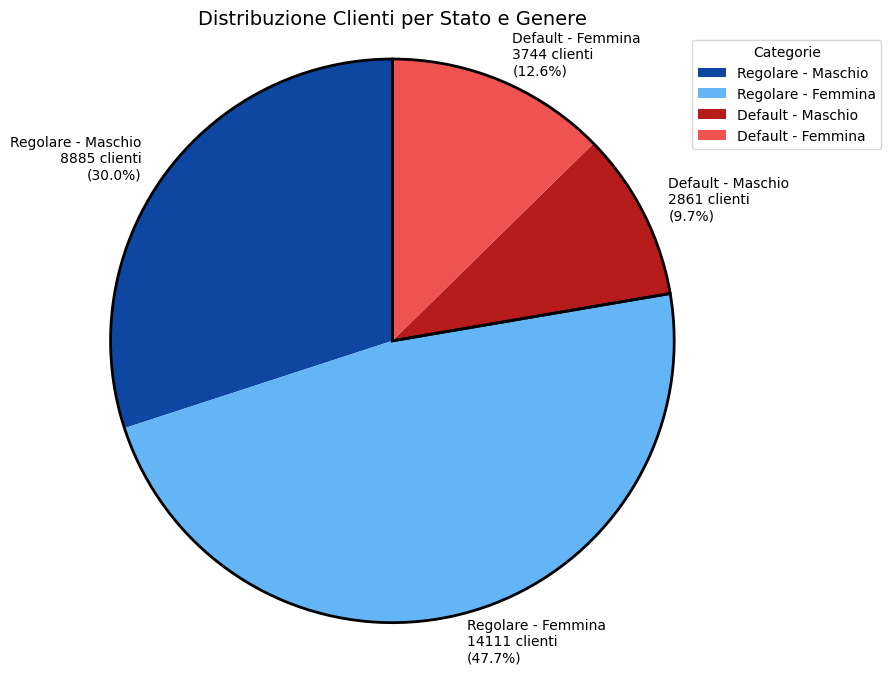

In [22]:
import matplotlib.pyplot as plt

# Mappiamo i valori di SEX
sex_map = {1: "Maschio", 2: "Femmina"}

# Creiamo una colonna combinata: Stato × Genere
df_clean["Status_Gender"] = df_clean.apply(
    lambda row: (
        "Regolare - " + sex_map[row["SEX"]] if row["default payment next month"] == 0
        else "Default - " + sex_map[row["SEX"]]
    ),
    axis=1
)

# Conteggi 4 categorie
counts4 = df_clean["Status_Gender"].value_counts()

order4 = [
    "Regolare - Maschio",
    "Regolare - Femmina",
    "Default - Maschio",
    "Default - Femmina"
]

counts4 = counts4.reindex(order4)

colors4 = [
    "#0D47A1",  # blu scuro - regolare maschio
    "#64B5F6",  # blu chiaro - regolare femmina
    "#B71C1C",  # rosso scuro - default maschio
    "#EF5350"   # rosso chiaro - default femmina
]

# Conteggi 2 categorie (solo per la linea di separazione)
counts2 = df_clean["default payment next month"].value_counts().sort_index()
colors2 = ["none", "none"]  # invisibili

plt.figure(figsize=(8, 8))

# --- PIE PRINCIPALE (4 spicchi) ---
plt.pie(
    counts4,
    labels=[f"{label}\n{counts4[label]} clienti\n({counts4[label]/counts4.sum()*100:.1f}%)" for label in order4],
    colors=colors4,
    startangle=90,
    autopct=None
)

# --- PIE SOVRAPPOSTA (2 spicchi, solo bordo) ---
plt.pie(
    counts2,
    radius=1.0,
    colors=colors2,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'black'}  # <--- SOLO QUESTA LINEA DIVIDE I DUE GRUPPI
)

plt.title("Distribuzione Clienti per Stato e Genere", fontsize=14)
plt.axis("equal")

plt.legend(
    order4,
    title="Categorie",
    loc="upper right",
    bbox_to_anchor=(1.3, 1)
)

plt.show()


*La rappresentazione percentuale dei clienti in default evidenzia un forte sbilanciamento del dataset: la maggior parte dei clienti risulta regolare, mentre circa un quinto presenta insolvenza. Questo conferma la necessità di adottare metriche e tecniche adeguate per la gestione di dataset sbilanciati.*

**Limite di Credito vs Default**

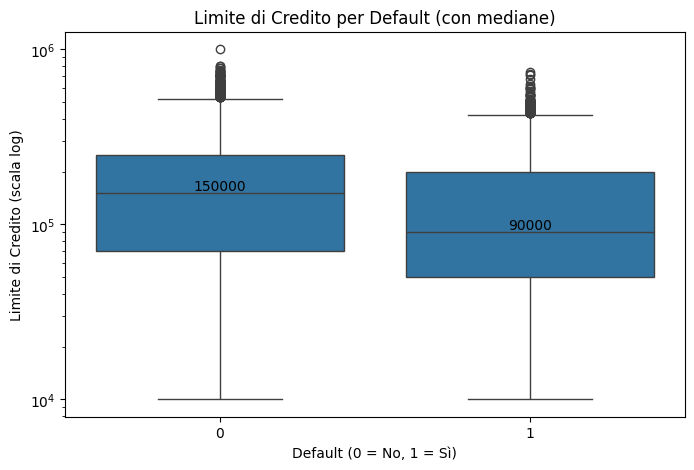

In [23]:
import numpy as np

plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df_clean)
plt.yscale('log')

medians = df_clean.groupby('default payment next month')['LIMIT_BAL'].median()

for i, median in enumerate(medians):
    ax.text(i, median, f"{median:.0f}", ha='center', va='bottom', fontsize=10, color='black')

plt.title('Limite di Credito per Default (con mediane)')
plt.xlabel('Default (0 = No, 1 = Sì)')
plt.ylabel('Limite di Credito (scala log)')

plt.show()


*Il boxplot mostra che i clienti in default hanno limiti di credito mediamente più bassi rispetto ai clienti regolari. La mediana scende da 150.000 per i regolari a 90.000 per gli insolventi, indicando che i clienti considerati più rischiosi ricevono limiti più contenuti. La scala logaritmica evidenzia inoltre una maggiore variabilità tra i clienti regolari rispetto ai default.*

**Impatto del ritardo nei pagamenti
chi accumula 1 o 2 mesi di ritardo a settembre ha una probabilità altissima di andare in default il mese successivo.**

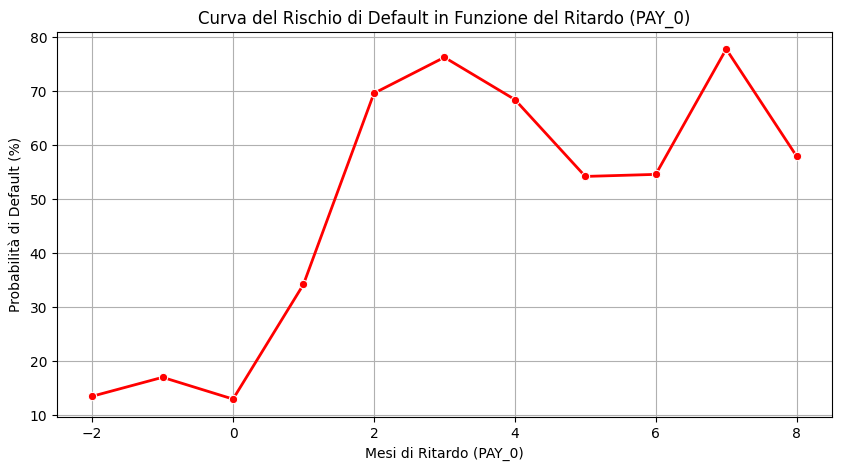

In [24]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=default_per_ritardo.index, y=default_per_ritardo.values, marker="o", linewidth=2, color="red")

plt.title("Curva del Rischio di Default in Funzione del Ritardo (PAY_0)")
plt.xlabel("Mesi di Ritardo (PAY_0)")
plt.ylabel("Probabilità di Default (%)")

plt.grid(True)
plt.show()

*La curva del rischio mostra una relazione fortemente crescente tra il ritardo nei pagamenti (PAY_0) e la probabilità di default. I clienti puntuali presentano un rischio molto basso, mentre già con un mese di ritardo la probabilità di insolvenza aumenta drasticamente. Con due mesi di ritardo il rischio diventa estremamente elevato, confermando PAY_0 come uno dei predittori più significativi del default.*

# Fase 4 Modellazione

#**4.1 Creazione del train e del test**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Rimuoviamo eventuali colonne create solo per i grafici e non utili alla modellazione
df_model = df_clean.drop(columns=["Status_Gender"], errors="ignore")

# Separiamo le feature dal target
X = df_model.drop(columns=["default payment next month", "ID"])
y = df_model["default payment next month"]

# Suddivisione 80% train, 20% test con stratificazione
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardizzazione
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print di controllo
print("Preparazione dati completata.")
print("Dimensioni X_train:", X_train.shape)
print("Dimensioni X_test:", X_test.shape)
print("Dimensioni y_train:", y_train.shape)
print("Dimensioni y_test:", y_test.shape)

print("\nDistribuzione DEFAULT nel train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuzione DEFAULT nel test:")
print(y_test.value_counts(normalize=True) * 100)

print("\nColonne usate per la modellazione:")
print(list(X.columns))

print("\nStandardizzazione completata.")
print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled:", X_test_scaled.shape)

Preparazione dati completata.
Dimensioni X_train: (23680, 23)
Dimensioni X_test: (5921, 23)
Dimensioni y_train: (23680,)
Dimensioni y_test: (5921,)

Distribuzione DEFAULT nel train:
default payment next month
0    77.685811
1    22.314189
Name: proportion, dtype: float64

Distribuzione DEFAULT nel test:
default payment next month
0    77.689579
1    22.310421
Name: proportion, dtype: float64

Colonne usate per la modellazione:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Standardizzazione completata.
Shape X_train_scaled: (23680, 23)
Shape X_test_scaled: (5921, 23)


La procedura di train-test split non modifica il dataset originale, ma genera quattro insiemi distinti (X_train, X_test, y_train e y_test) utilizzati esclusivamente per l'addestramento e la valutazione dei modelli di classificazione. Il dataframe di partenza rimane invariato e può essere riutilizzato per ulteriori analisi esplorative o per replicare la suddivisione con parametri differenti.

Il dataset è stato suddiviso in un insieme di addestramento (80%) e in un insieme di test (20%) mediante train-test split con stratificazione rispetto alla variabile target. La stratificazione garantisce che la proporzione di clienti insolventi (circa il 22%) e di clienti regolari sia mantenuta in entrambi gli insiemi, consentendo una valutazione più rappresentativa e affidabile delle prestazioni dei modelli.

Successivamente è stata applicata la standardizzazione delle variabili numeriche mediante StandardScaler. Questo passaggio è stato introdotto perché alcuni algoritmi, come Logistic Regression e K-Nearest Neighbors, sono sensibili alla diversa scala delle variabili. La standardizzazione consente di rendere confrontabili feature con ordini di grandezza molto differenti, evitando che variabili come LIMIT_BAL o BILL_AMT influenzino il modello più di altre esclusivamente a causa della loro scala numerica. Per il modello Random Forest, invece, la standardizzazione non è strettamente necessaria, ma è stata comunque eseguita per mantenere una procedura di preparazione dei dati coerente tra i diversi modelli.

Logistic Regression addestrata con successo.
Risultati Logistic Regression
Accuracy: 0.8098294207059619
Precision: 0.7200902934537246
Recall: 0.24148372445117336
F1-score: 0.36167800453514737

Confusion Matrix:
[[4476  124]
 [1002  319]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4600
           1       0.72      0.24      0.36      1321

    accuracy                           0.81      5921
   macro avg       0.77      0.61      0.62      5921
weighted avg       0.80      0.81      0.77      5921



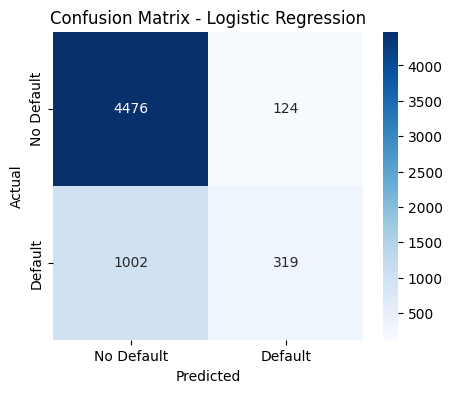

In [26]:
## 4.2 Logistic Regression

#Il primo modello utilizzato è la Logistic Regression, un modello lineare adatto ai problemi di classificazione binaria. Nel nostro caso viene usato per stimare se un cliente andrà o meno in default nel mese successivo.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Creazione del modello
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Addestramento sui dati standardizzati
log_reg.fit(X_train_scaled, y_train)

# Predizione sul test set
y_pred_logreg = log_reg.predict(X_test_scaled)

print("Logistic Regression addestrata con successo.")


### Valutazione Logistic Regression

# Calcolo metriche Logistic Regression
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("Risultati Logistic Regression")
print("Accuracy:", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall:", recall_logreg)
print("F1-score:", f1_logreg)

print("\nConfusion Matrix:")
print(cm_logreg)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))


plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#La Logistic Regression rappresenta un modello di base utile per confrontare le prestazioni degli algoritmi successivi. Il modello è facilmente interpretabile, ma può avere limiti nel cogliere relazioni non lineari tra le variabili. Poiché il dataset è sbilanciato, l’accuracy deve essere interpretata insieme a precision, recall e f1-score.